# RETRIEVAL

**What was wrong before:** the FAISS index was built at execution 19, but the junk
filters ran at executions 22–23. The index therefore held 5,924 chunks while BM25
held 5,138 — the two retrievers were searching *different corpora*, which
confounded the BM25 ablation row.

**The build order below is load-bearing.** Two rules:

1. `chunk_id` is assigned **once**, immediately after the `MIN_CHARS` filter, and
   never again. Content filters run *after*. This means changing a filter never
   renumbers chunks, so a saved eval set stays valid. Filtered IDs have gaps —
   gaps are fine; stability is what matters.
2. `corpus` and the FAISS index are both built **after all filtering**, from the
   same `docs_processed` list. Cell 12 asserts all three stores agree.

Run top to bottom. Stop at any failed assertion.

In [1]:
import numpy as np 
import pandas as pd 

!pip install langchain_text_splitters langchain_huggingface langchain_community faiss-cpu

## 1 · Download the filings from EDGAR

Cached on disk — re-running costs nothing.

In [2]:
import requests, time, hashlib, json
from pathlib import Path

CACHE = Path("edgar_cache"); CACHE.mkdir(exist_ok=True)
# SEC asks for contact details in the User-Agent. They are kept out of the code so
# no personal e-mail gets published. On Kaggle: Add-ons > Secrets > add SEC_USER_AGENT
# with a value like "Your Name you@example.com", and attach it to this notebook.
import os
try:
    from kaggle_secrets import UserSecretsClient
    os.environ.setdefault("SEC_USER_AGENT", UserSecretsClient().get_secret("SEC_USER_AGENT"))
except Exception:
    pass                                   # not on Kaggle: export SEC_USER_AGENT in the shell
HEADERS = {"User-Agent": os.environ["SEC_USER_AGENT"]}   # KeyError = secret not set

_last_call = [0.0]
def polite_get(url: str, binary=False):
    # 1. serve from disk if we already have it (filings never change once published)
    key = hashlib.md5(url.encode()).hexdigest()
    cached = CACHE / (key + (".bin" if binary else ".txt"))
    if cached.exists():
        return cached.read_bytes() if binary else cached.read_text(encoding="utf-8")

    # 2. throttle: keep a >=150ms gap between live calls (SEC limit is 10/sec)
    gap = time.time() - _last_call[0]
    if gap < 0.15:
        time.sleep(0.15 - gap)
    _last_call[0] = time.time()

    r = requests.get(url, headers=HEADERS, timeout=30)
    r.raise_for_status()
    (cached.write_bytes(r.content) if binary else
     cached.write_text(r.text, encoding="utf-8"))
    return r.content if binary else r.text


def load_ticker_map():
    data = json.loads(polite_get("https://www.sec.gov/files/company_tickers.json"))
    return {row["ticker"].upper(): row for row in data.values()}

TICKERS = load_ticker_map()

def cik_for(ticker: str) -> str:
    return str(TICKERS[ticker.upper()]["cik_str"]).zfill(10)

In [3]:
def find_10ks(ticker: str, n_years: int = 3):
    cik = cik_for(ticker)
    subs = json.loads(polite_get(f"https://data.sec.gov/submissions/CIK{cik}.json"))
    recent = subs["filings"]["recent"]        # parallel arrays, one index per filing

    rows = []
    for i, form in enumerate(recent["form"]):
        if form != "10-K":                    # exact match: excludes 10-K/A amendments
            continue
        rows.append({
            "ticker": ticker.upper(),
            "company": subs["name"],
            "cik": cik,
            "accession": recent["accessionNumber"][i],
            "primary_doc": recent["primaryDocument"][i],
            "filing_date": recent["filingDate"][i],
            "report_date": recent["reportDate"][i],   # period of report
            "fiscal_year": recent["reportDate"][i][:4],
            # fiscal_year comes from reportDate, NOT filingDate. NVIDIA's FY2026
            # ends in January 2026 but is filed later; using filingDate would
            # mislabel it.
        })
    return rows[:n_years]                     # already newest-first


def download_filing(row: dict) -> str:
    accn_nodash = row["accession"].replace("-", "")
    url = (f"https://www.sec.gov/Archives/edgar/data/"
           f"{int(row['cik'])}/{accn_nodash}/{row['primary_doc']}")
    row["source_url"] = url
    return polite_get(url)


from bs4 import BeautifulSoup

def html_to_text(html: str) -> str:
    soup = BeautifulSoup(html, "html.parser")
    for tag in soup(["script", "style"]):
        tag.decompose()
    text = soup.get_text(separator="\n")
    lines = [ln.strip() for ln in text.splitlines() if ln.strip()]
    return "\n".join(lines)

In [4]:
OUT = Path("corpus"); OUT.mkdir(exist_ok=True)

# The exact 15 filings behind every result in this notebook (= data/manifest_pinned.json).
# "Newest 3" would change when a company files its next 10-K (Apple: every autumn),
# shifting chunk IDs and breaking the gold labels. Pinning makes re-runs identical.
PINNED_ACCESSIONS = {
    "0000320193-25-000079",
    "0000320193-24-000123",
    "0000320193-23-000106",
    "0001193125-26-323660",
    "0000950170-25-100235",
    "0000950170-24-087843",
    "0001045810-26-000021",
    "0001045810-25-000023",
    "0001045810-24-000029",
    "0001652044-26-000018",
    "0001652044-25-000014",
    "0001652044-24-000022",
    "0001018724-26-000004",
    "0001018724-25-000004",
    "0001018724-24-000008",
}

def build_corpus(tickers, n_years=3):
    manifest = []
    for tk in tickers:
        rows = [r for r in find_10ks(tk, n_years=20) if r["accession"] in PINNED_ACCESSIONS]
        assert len(rows) == n_years, f"{tk}: found {len(rows)} pinned filings, expected {n_years}"
        for row in rows:
            html = download_filing(row)              # fills in source_url
            text = html_to_text(html)
            name = f"{row['ticker']}_{row['fiscal_year']}"
            (OUT / f"{name}.txt").write_text(text, encoding="utf-8")
            row["char_len"] = len(text)              # integrity check at load time
            row["filename"] = f"{name}.txt"          # never rebuild this string later
            manifest.append(row)
    (OUT / "manifest.jsonl").write_text(
        "\n".join(json.dumps(r) for r in manifest), encoding="utf-8")
    return manifest

TECH = ["AAPL", "MSFT", "NVDA", "GOOGL", "AMZN"]
manifest = build_corpus(TECH, n_years=3)
print(f"{len(manifest)} filings in manifest")
print(manifest)

15 filings in manifest
[{'ticker': 'AAPL', 'company': 'Apple Inc.', 'cik': '0000320193', 'accession': '0000320193-25-000079', 'primary_doc': 'aapl-20250927.htm', 'filing_date': '2025-10-31', 'report_date': '2025-09-27', 'fiscal_year': '2025', 'source_url': 'https://www.sec.gov/Archives/edgar/data/320193/000032019325000079/aapl-20250927.htm', 'char_len': 220666, 'filename': 'AAPL_2025.txt'}, {'ticker': 'AAPL', 'company': 'Apple Inc.', 'cik': '0000320193', 'accession': '0000320193-24-000123', 'primary_doc': 'aapl-20240928.htm', 'filing_date': '2024-11-01', 'report_date': '2024-09-28', 'fiscal_year': '2024', 'source_url': 'https://www.sec.gov/Archives/edgar/data/320193/000032019324000123/aapl-20240928.htm', 'char_len': 218687, 'filename': 'AAPL_2024.txt'}, {'ticker': 'AAPL', 'company': 'Apple Inc.', 'cik': '0000320193', 'accession': '0000320193-23-000106', 'primary_doc': 'aapl-20230930.htm', 'filing_date': '2023-11-03', 'report_date': '2023-09-30', 'fiscal_year': '2023', 'source_url': 'ht

## 2 · Load into LangChain documents

The **manifest drives the loop**, not `glob`. A missing file then raises instead of silently shrinking the corpus.

In [5]:
from langchain_core.documents import Document as LangchainDocument
from collections import Counter

CORPUS = Path("corpus")

# Explicit whitelist. This metadata rides into every chunk and then into FAISS,
# so it is a deliberate choice, not a dump of whatever the manifest holds.
KEEP = ("ticker", "company", "cik", "fiscal_year",
        "report_date", "filing_date", "source_url", "accession")

RAW_KNOWLEDGE_BASE, seen = [], set()

with open(CORPUS / "manifest.jsonl", encoding="utf-8") as f:
    for line in f:
        if not line.strip():
            continue
        r = json.loads(line)

        path = CORPUS / r["filename"]           # no string reconstruction
        text = path.read_text(encoding="utf-8") # missing file -> raises, loudly

        if len(text) != r["char_len"]:          # file changed since download
            raise ValueError(f"{path.name}: manifest {r['char_len']:,} vs file {len(text):,}")
        if path.stem in seen:                   # two filings collide on TICKER_YEAR
            raise ValueError(f"duplicate corpus entry: {path.stem}")
        seen.add(path.stem)

        RAW_KNOWLEDGE_BASE.append(LangchainDocument(
            page_content=text,
            metadata={"source": path.stem, **{k: r[k] for k in KEEP}}))

print(f"{len(RAW_KNOWLEDGE_BASE)} filings loaded")
print(Counter(d.metadata["ticker"] for d in RAW_KNOWLEDGE_BASE))   # expect 3 each

15 filings loaded
Counter({'AAPL': 3, 'MSFT': 3, 'NVDA': 3, 'GOOGL': 3, 'AMZN': 3})


## 3 · Split into chunks

Character-based, not token-based. `from_huggingface_tokenizer` re-tokenises every
candidate split; on 15 × ~350 KB filings that runs for many minutes. Split by
characters with a margin, then **measure** the token lengths in section 5 — which
makes that histogram load-bearing rather than decorative.

In [6]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

CHUNK_CHARS   = 1100
CHUNK_OVERLAP = 200          # ~18% — carries a sentence across the boundary so a
                             # fact split in half is still findable

# Tried in order; the splitter falls through only when a piece is still too big.
# SEC text is plain prose, NOT markdown — "\n### " and "```" would never fire.
SEC_SEPARATORS = ["\n\n", "\n", ". ", " ", ""]

splitter = RecursiveCharacterTextSplitter(
    chunk_size=CHUNK_CHARS,
    chunk_overlap=CHUNK_OVERLAP,
    separators=SEC_SEPARATORS,
    add_start_index=True,     # where in the filing this chunk began
    strip_whitespace=True,
)

docs_processed = []
for doc in RAW_KNOWLEDGE_BASE:
    pieces = splitter.split_documents([doc])   # metadata copied to each piece
    docs_processed.extend(pieces)
    print(f"{doc.metadata['source']:<12} {len(doc.page_content):>8,} chars "
          f"→ {len(pieces):>5} chunks")

print(f"\nTOTAL: {len(docs_processed):,} chunks")

AAPL_2025     220,666 chars →   270 chunks
AAPL_2024     218,687 chars →   270 chunks
AAPL_2023     216,738 chars →   268 chunks
MSFT_2026     357,714 chars →   433 chunks
MSFT_2025     347,437 chars →   423 chunks
MSFT_2024     390,462 chars →   481 chunks
NVDA_2026     360,462 chars →   454 chunks
NVDA_2025     368,220 chars →   468 chunks
NVDA_2024     358,853 chars →   455 chunks
GOOGL_2025    384,115 chars →   464 chunks
GOOGL_2024    381,674 chars →   462 chunks
GOOGL_2023    371,213 chars →   450 chunks
AMZN_2025     312,366 chars →   384 chunks
AMZN_2024     308,442 chars →   381 chunks
AMZN_2023     311,544 chars →   386 chunks

TOTAL: 6,049 chunks


## 4 · Length filter, then FREEZE the IDs

**Order matters and this is the fix.** `chunk_id` is assigned here, once, and never
again. Content filters run *after*, so removing junk leaves gaps in the numbering
rather than renumbering everything.

Why that is the right way round: if IDs were assigned after filtering, then editing
a filter would shift every ID, and the gold IDs in your saved eval set would point
at different text — with nothing raising an error.

In [7]:
MIN_CHARS = 200          # page numbers, table borders, TOC fragments

before = len(docs_processed)
docs_processed = [d for d in docs_processed if len(d.page_content) >= MIN_CHARS]
print(f"dropped {before - len(docs_processed):,} chunks shorter than {MIN_CHARS} chars")

dropped 125 chunks shorter than 200 chars


In [8]:
from collections import defaultdict

# ---- ID ASSIGNMENT. RUN ONCE. NEVER RE-RUN AFTER THIS POINT. ----------------
counter = defaultdict(int)
for d in docs_processed:
    src = d.metadata["source"]                       # e.g. "AAPL_2025"
    d.metadata["chunk_id"] = f"{src}__{counter[src]:04d}"
    counter[src] += 1

# Readable IDs over opaque ones: when retrieval fails you can see at a glance
# that an Amazon chunk came back for an Apple question. Free diagnosis.
all_ids = [d.metadata["chunk_id"] for d in docs_processed]
assert len(all_ids) == len(set(all_ids)), "duplicate chunk_id"

print(f"{len(docs_processed):,} chunks, IDs frozen and unique")
print("first id:", all_ids[0], "| last id:", all_ids[-1])

5,924 chunks, IDs frozen and unique
first id: AAPL_2025__0000 | last id: AMZN_2023__0376


## 5 · Content filters

Two families of junk, caught by two different rules:

* **machine-generated** — XBRL tag soup, digit-dense table fragments
* **human administrative** — exhibit indexes, signature pages, tables of contents

Both are real text that can never answer a question but *can* be retrieved,
evicting a real chunk from the top-k.

In [9]:
import re

def is_junk(text: str) -> bool:
    """Machine-generated metadata."""
    # XBRL dumps are dense in "prefix:TagName" tokens
    if len(re.findall(r"\b(us-gaap|dei|srt|msft|nvda|aapl|amzn|goog):", text)) >= 5:
        return True
    # Mostly digits and punctuation -> table fragment
    if sum(c.isalpha() for c in text) / max(len(text), 1) < 0.55:
        return True
    return False


def is_front_matter(text: str) -> bool:
    """Human-written administrative pages."""
    t = text

    # Signature pages, both spacings EDGAR produces
    if t.count("/ S /") >= 2 or "POWER OF ATTORNEY" in t.upper():
        return True
    if re.search(r"/s/\s*[A-Z]", t) and "SIGNATURES" in t.upper():
        return True

    # Exhibit indexes cross-reference other filings constantly.
    # Counting FORM TYPES, not exhibit numbers: "10.8" and "4.17" look identical
    # to "$3.5 billion" and "198.89", so a decimal-counting rule would delete
    # your financial tables.
    if len(re.findall(r"\b(8-K|10-Q|10-K)\b", t)) >= 4:
        return True
    if "Index to Exhibits" in t or "Exhibit Number" in t:
        return True

    # Table of contents: a wall of Item headings
    if len(re.findall(r"Item\s+\d+[A-C]?\.", t)) >= 5:
        return True

    # Cover page markers
    if "DOCUMENTS INCORPORATED BY REFERENCE" in t.upper():
        return True
    if t.count("Indicate by check mark") >= 2:
        return True

    return False

In [10]:
# INSPECT BEFORE DELETING. A filter that eats revenue tables is worse than none.
import random
random.seed(0)

would_drop = [d for d in docs_processed
              if is_junk(d.page_content) or is_front_matter(d.page_content)]
print(f"would drop {len(would_drop):,} of {len(docs_processed):,} "
      f"({len(would_drop)/len(docs_processed):.1%})\n")

for d in random.sample(would_drop, min(8, len(would_drop))):
    print("=" * 70)
    print(d.metadata["chunk_id"])
    print(d.page_content[:200].replace("\n", " "))

# Read all 8. If ANY is real content, tighten the rule before running the next cell.

would drop 835 of 5,924 (14.1%)

NVDA_2025__0013
2024-01-28 0001045810 us-gaap:ForeignExchangeForwardMember us-gaap:NondesignatedMember 2025-01-26 0001045810 us-gaap:ForeignExchangeForwardMember us-gaap:NondesignatedMember 2024-01-28 0001045810 us-g
AMZN_2023__0003
0001018724 us-gaap:AccumulatedOtherComprehensiveIncomeMember 2021-12-31 0001018724 us-gaap:RetainedEarningsMember 2021-12-31 0001018724 us-gaap:RetainedEarningsMember 2022-01-01 2022-12-31 0001018724 
NVDA_2024__0006
2024-01-28 0001045810 us-gaap:ShareBasedCompensationAwardTrancheOneMember us-gaap:RestrictedStockUnitsRSUMember 2023-01-30 2024-01-28 0001045810 us-gaap:RestrictedStockUnitsRSUMember us-gaap:ShareBase
AAPL_2025__0258
8-K 4.1 5/24/17 4.16 Officer’s Certificate of the Registrant, dated as of June 20, 2017, including form of global note representing the 3.000% Notes due 2027. 8-K 4.1 6/20/17 4.17 Officer’s Certificat
MSFT_2025__0405
8-K 4.9 11/6/2023 4.20 Base Indenture, dated as of May 26, 2017, by and between Act

In [11]:
before = len(docs_processed)
docs_processed = [d for d in docs_processed if not is_junk(d.page_content)]
print(f"dropped {before - len(docs_processed):,} machine-junk chunks")

before = len(docs_processed)
docs_processed = [d for d in docs_processed if not is_front_matter(d.page_content)]
print(f"dropped {before - len(docs_processed):,} front-matter chunks")

print(f"\nFINAL CORPUS: {len(docs_processed):,} chunks")

dropped 610 machine-junk chunks
dropped 225 front-matter chunks

FINAL CORPUS: 5,089 chunks


## 6 · Token histogram

`bge-base-en-v1.5` truncates at 512 tokens **silently**. A too-long chunk still gets indexed and retrieved, but its tail was never represented. Only this plot reveals it.

median 177 | p95 281 | max 473 | OVER 512: 0.0%


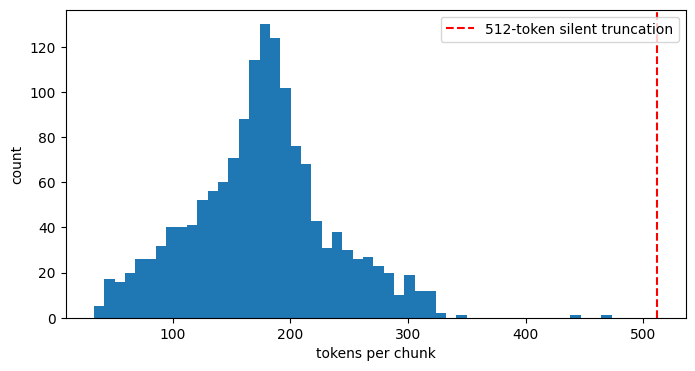

In [12]:
import matplotlib.pyplot as plt
import numpy as np
from transformers import AutoTokenizer

EMBEDDING_MODEL_NAME = "BAAI/bge-base-en-v1.5"
MAX_SEQ_LEN = 512

tokenizer = AutoTokenizer.from_pretrained(EMBEDDING_MODEL_NAME)

# Sample rather than tokenise everything — same shape, a fraction of the time.
rng = np.random.default_rng(0)
idx = rng.choice(len(docs_processed), size=min(1500, len(docs_processed)), replace=False)
lengths = np.array([len(tokenizer.encode(docs_processed[i].page_content)) for i in idx])

print(f"median {np.median(lengths):.0f} | p95 {np.percentile(lengths,95):.0f} | "
      f"max {lengths.max()} | OVER {MAX_SEQ_LEN}: {(lengths>MAX_SEQ_LEN).mean():.1%}")

plt.figure(figsize=(8, 4))
plt.hist(lengths, bins=50)
plt.axvline(MAX_SEQ_LEN, color="red", ls="--", label="512-token silent truncation")
plt.xlabel("tokens per chunk"); plt.ylabel("count"); plt.legend(); plt.show()

# 0% over -> good. Under ~2% -> note it in the README. More -> lower CHUNK_CHARS
# and re-run from section 3.

## 7 · Embed and index — **after** all filtering

In [13]:
import torch
from langchain_huggingface import HuggingFaceEmbeddings

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

embedding_model = HuggingFaceEmbeddings(
    model_name=EMBEDDING_MODEL_NAME,
    model_kwargs={"device": device},
    encode_kwargs={"normalize_embeddings": True,   # unit vectors -> dot == cosine
                   "batch_size": 32},
    multi_process=False,                           # True often hangs on Kaggle
)

# bge-v1.5 is ASYMMETRIC: passages go in bare, queries go in with an instruction
# prefix. Omitting this silently costs recall.
BGE_QUERY_PREFIX = "Represent this sentence for searching relevant passages: "
print("embedding model loaded")

device: cuda


BertModel LOAD REPORT from: BAAI/bge-base-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


embedding model loaded


In [14]:
import warnings, time
warnings.filterwarnings("ignore", category=DeprecationWarning, module="langchain_community")

from langchain_community.vectorstores import FAISS
from langchain_community.vectorstores.utils import DistanceStrategy

# Embed FIRST and keep the vectors. If index construction fails (a missing faiss
# install, say), you do not lose the expensive step and have to redo it.
texts     = [d.page_content for d in docs_processed]
metadatas = [d.metadata     for d in docs_processed]

t0 = time.time()
vectors = embedding_model.embed_documents(texts)
print(f"embedded {len(vectors):,} chunks in {time.time()-t0:.0f}s")

KNOWLEDGE_VECTOR_DATABASE = FAISS.from_embeddings(
    text_embeddings=list(zip(texts, vectors)),
    embedding=embedding_model,
    metadatas=metadatas,
    distance_strategy=DistanceStrategy.COSINE,
)
KNOWLEDGE_VECTOR_DATABASE.save_local("faiss_index_sec")
print(f"indexed {KNOWLEDGE_VECTOR_DATABASE.index.ntotal:,} chunks -> faiss_index_sec/")

# NOTE: langchain_community maps DistanceStrategy.COSINE to IndexFlatL2 — only
# MAX_INNER_PRODUCT gets special treatment. Because normalize_embeddings=True,
# ||a-b||^2 = 2 - 2*cos(a,b), so the returned scores are DISTANCES: lower = better.

/tmp/ipykernel_58/3439609456.py:4: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.vectorstores import FAISS


embedded 5,089 chunks in 73s
indexed 5,089 chunks -> faiss_index_sec/


## 8 · The three stores, and the assertion that would have caught the bug

In [15]:
def retrieve(query: str, k: int = 5):
    """Top-k chunk_ids for a query, best first. THE dense entry point."""
    qvec = embedding_model.embed_query(BGE_QUERY_PREFIX + query)
    docs = KNOWLEDGE_VECTOR_DATABASE.similarity_search_by_vector(qvec, k=k)
    return [d.metadata["chunk_id"] for d in docs]


def retrieve_verbose(query: str, k: int = 5):
    """Same retrieval, returning (distance, metadata, text) for human reading."""
    qvec = embedding_model.embed_query(BGE_QUERY_PREFIX + query)
    pairs = KNOWLEDGE_VECTOR_DATABASE.similarity_search_with_score_by_vector(qvec, k=k)
    return [(s, d.metadata, d.page_content) for d, s in pairs]


corpus = {d.metadata["chunk_id"]: d.page_content for d in docs_processed}

# Recover vectors from FAISS rather than re-embedding — needed by MMR later.
_n    = KNOWLEDGE_VECTOR_DATABASE.index.ntotal
_all  = KNOWLEDGE_VECTOR_DATABASE.index.reconstruct_n(0, _n)
_i2d  = KNOWLEDGE_VECTOR_DATABASE.index_to_docstore_id
_store = KNOWLEDGE_VECTOR_DATABASE.docstore
chunk_vec = {_store.search(_i2d[i]).metadata["chunk_id"]: _all[i] for i in range(_n)}

print(f"docs_processed {len(docs_processed):,} | corpus {len(corpus):,} | "
      f"faiss {len(chunk_vec):,}")

docs_processed 5,089 | corpus 5,089 | faiss 5,089


In [16]:
# ---- THE GUARD. This is the assertion whose absence caused the last bug. ----
assert len(chunk_vec) == len(corpus) == len(docs_processed), (
    f"DESYNC — faiss:{len(chunk_vec)} corpus:{len(corpus)} docs:{len(docs_processed)}")
assert set(chunk_vec) == set(corpus), "DESYNC — id sets differ"
print("PASS: index, corpus and document list are aligned")

PASS: index, corpus and document list are aligned


## 8b · Export the index for GitHub and the public demo

Writes `artifacts/chunks.jsonl` + `artifacts/embeddings.npy`, the exact format
`rag/store.py` reads. Run once, then download the `artifacts/` folder from Kaggle's
**Output** panel and place it in the repo. Plain JSON + NumPy instead of the LangChain
FAISS folder, because loading that folder requires unpickling (running code from a file).

In [ ]:
import json
ART = Path("artifacts"); ART.mkdir(exist_ok=True)
META_OUT = ("source",) + KEEP          # same keys as rag/config.py META_KEYS

with open(ART / "chunks.jsonl", "w", encoding="utf-8") as f:
    for d in docs_processed:
        f.write(json.dumps({"chunk_id": d.metadata["chunk_id"],
                            "text": d.page_content,
                            "meta": {k: d.metadata[k] for k in META_OUT}},
                           ensure_ascii=False) + "\n")

# Row i of the matrix belongs to line i of chunks.jsonl.
vecs = np.stack([chunk_vec[d.metadata["chunk_id"]] for d in docs_processed]).astype("float32")
np.save(ART / "embeddings.npy", vecs)
(ART / "info.json").write_text(json.dumps({"n_chunks": len(docs_processed), "dim": int(vecs.shape[1]),
                                           "embedding_model": EMBEDDING_MODEL_NAME,
                                           "normalized": True}, indent=2))

assert len(vecs) == len(docs_processed) == len(corpus)
assert np.allclose(np.linalg.norm(vecs, axis=1), 1.0, atol=1e-3), "vectors not unit length"
print(f"exported {len(vecs):,} chunks, {vecs.nbytes/1e6:.1f} MB of vectors -> {ART}/")

## 9 · Eyeball one query before trusting any number

In [17]:
question = "What are the main risk factors related to supply chain disruption?"

print(f"QUESTION: {question}\n" + "=" * 78)
for rank, (dist, meta, text) in enumerate(retrieve_verbose(question, k=5), 1):
    print(f"\n[{rank}] cos={1 - dist/2:.4f}  id={meta['chunk_id']}  "
          f"{meta['ticker']} FY{meta['fiscal_year']}")
    print("    " + text[:300].replace("\n", " ") + " ...")

# Judge three things:
#   1. on topic, not boilerplate headers?
#   2. spread across companies, or all one ticker?
#   3. readable English, or table wreckage?

QUESTION: What are the main risk factors related to supply chain disruption?

[1] cos=0.7367  id=NVDA_2026__0147  NVDA FY2026
    Business disruptions could harm our operations, lead to a decline in revenue and increase our costs. Factors that have caused and/or could in the future cause disruptions to our worldwide operations include: natural disasters, extreme weather conditions, power or water shortages, critical infrastruc ...

[2] cos=0.7308  id=NVDA_2025__0103  NVDA FY2025
    Risk Factors Summary Risks Related to Our Industry and Markets • Failure to meet the evolving needs of our industry and markets may adversely impact our financial results. • Competition could adversely impact our market share and financial results. Risks Related to Demand, Supply, and Manufacturing  ...

[3] cos=0.7274  id=NVDA_2024__0096  NVDA FY2024
    Risk Factors Summary Risks Related to Our Industry and Markets • Failure to meet the evolving needs of our industry may adversely impact our financial res

## 10 · Retrieval components

BM25, RRF, MMR, cross-encoder — then **one** search function that all ablation rows go through.

In [18]:
import math
from collections import Counter

class BM25:
    """
    Sparse lexical scorer. Three ideas:
      1. rare words matter more        -> idf
      2. repetition saturates          -> k1 caps term-frequency gain
      3. long documents get discounted -> b normalises by length
    """
    def __init__(self, ids, texts, k1=1.5, b=0.75):
        self.k1, self.b, self.ids = k1, b, ids
        self.docs  = [self._tok(t) for t in texts]
        self.lens  = [len(d) for d in self.docs]
        self.avgdl = sum(self.lens) / len(self.lens)

        # Inverted index: term -> [(doc_index, term_freq)]. Without it every query
        # scans the whole corpus; with it you touch only matching documents.
        self.index = defaultdict(list)
        df = Counter()
        for i, doc in enumerate(self.docs):
            for term, tf in Counter(doc).items():
                self.index[term].append((i, tf))
                df[term] += 1

        N = len(self.docs)
        # The 1e-6 floor stops terms in >half the corpus scoring NEGATIVE.
        # In 10-Ks that is "company", "risk", "results".
        self.idf = {t: max(math.log((N - n + 0.5) / (n + 0.5) + 1), 1e-6)
                    for t, n in df.items()}

    @staticmethod
    def _tok(text):
        return re.findall(r"[a-z0-9]+", text.lower())

    def search(self, query, k=50):
        scores = defaultdict(float)
        for term in self._tok(query):
            if term not in self.index:
                continue
            idf = self.idf[term]
            for i, tf in self.index[term]:
                dl = 1 - self.b + self.b * self.lens[i] / self.avgdl
                scores[i] += idf * (tf * (self.k1 + 1)) / (tf + self.k1 * dl)
        top = sorted(scores.items(), key=lambda x: -x[1])[:k]
        return [self.ids[i] for i, _ in top]


# Built from THE SAME docs_processed as FAISS. That is the whole point.
bm25 = BM25([d.metadata["chunk_id"] for d in docs_processed],
            [d.page_content for d in docs_processed])
assert set(bm25.ids) == set(corpus), "BM25 corpus differs from FAISS corpus"
print(f"BM25 built over {len(bm25.ids):,} chunks — matches index")

BM25 built over 5,089 chunks — matches index


In [19]:
def rrf_scored(rank_lists, k=60):
    """
    Reciprocal Rank Fusion. Combines lists by POSITION, not score.

    Why position: BM25 scores are unbounded sums; cosine sits in [-1,1].
    Averaging them needs a normalisation you cannot justify. Rank 1 is rank 1
    in any scoring system. k=60 is from the original paper; it damps the head
    so one ranker cannot dominate.

    Returns {doc_id: score}. Returning the SCORE, not just an order, is what
    lets MMR downstream use the hybrid signal instead of recomputing relevance
    from dense cosine alone — the bug that made the old MMR discard BM25.
    """
    scores = defaultdict(float)
    for lst in rank_lists:
        for rank, doc_id in enumerate(lst, start=1):
            scores[doc_id] += 1.0 / (k + rank)
    return scores


def rrf(rank_lists, k=60):
    """Ordered-list form. Defined via rrf_scored so the two cannot drift."""
    s = rrf_scored(rank_lists, k=k)
    return sorted(s, key=lambda d: -s[d])

In [20]:
def mmr_hybrid(rel_scores, cand_ids, lam=0.95, top_n=10):
    """
    Maximal Marginal Relevance:
        lam * relevance - (1-lam) * max_similarity_to_already_selected

    Each term from the RIGHT source:
        relevance  <- fused RRF score  (dense AND lexical agreement)
        redundancy <- embedding cosine (what "similar" means)
    The old version used dense cosine for both, discarding BM25 entirely.

    MMR is NOT reranking: it runs during candidate selection and changes WHICH
    chunks survive. Reranking runs after and changes their ORDER.
    """
    cand_ids = [c for c in cand_ids if c in chunk_vec]
    if not cand_ids:
        return []
    M = np.stack([chunk_vec[c] for c in cand_ids])

    # SCALE. RRF scores sit near 1/60 ~ 0.016; cosine redundancy sits in [0,1].
    # Unscaled, redundancy swamps relevance and lam controls nothing.
    rel = np.array([rel_scores[c] for c in cand_ids], dtype="float32")
    rng_ = rel.max() - rel.min()
    rel = (rel - rel.min()) / rng_ if rng_ > 1e-9 else np.ones_like(rel)

    selected, remaining = [], list(range(len(cand_ids)))
    while remaining and len(selected) < top_n:
        if not selected:
            best = max(remaining, key=lambda i: rel[i])
        else:
            red = (M[remaining] @ M[selected].T).max(axis=1)
            best = remaining[int(np.argmax(lam * rel[remaining] - (1 - lam) * red))]
        selected.append(best); remaining.remove(best)
    return [cand_ids[i] for i in selected]

In [21]:
from sentence_transformers import CrossEncoder

# bi-encoder    : embeds query and chunk SEPARATELY. Must compress a chunk to 768
#                 numbers BEFORE knowing the query. Fast, precomputable.
# cross-encoder : feeds "query [SEP] chunk" through BERT TOGETHER; every query
#                 token attends to every chunk token. Far more accurate, far too
#                 slow for the whole corpus -> retrieve 50, rerank those 50.
reranker = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2",
                        max_length=512, device=device)

def rerank(query, cand_ids, top_n=10):
    if not cand_ids:
        return []
    scores = reranker.predict([(query, corpus[c]) for c in cand_ids],
                              batch_size=32, show_progress_bar=False)
    return [cand_ids[i] for i in np.argsort(-scores)[:top_n]]

print("reranker loaded")

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


reranker loaded


In [22]:
def search(query, *, use_bm25=True, use_mmr=False, use_rerank=False,
           candidate_k=50, rerank_n=30, lam=0.95, top_n=10):
    """
    ONE code path for every ablation row.

    Five separately-written search functions is how the confounded-ablation bug
    happened: a change made to one and not the others meant a row differed by
    two things instead of one. With flags, rows CANNOT differ except as set.

    Stage 1  candidates : dense, optionally fused with BM25 via RRF
    Stage 2  diversity  : MMR over the fused candidates          (optional)
    Stage 3  precision  : cross-encoder reranking                (optional)

    use_bm25=False still routes through RRF with one list. RRF on a single list
    is order-preserving (1/(60+rank) strictly decreases), so dense-only results
    are identical to calling retrieve() directly — with one code path kept.
    """
    lists = [retrieve(query, k=candidate_k)]
    if use_bm25:
        lists.append(bm25.search(query, k=candidate_k))

    scores = rrf_scored(lists)
    cands  = sorted(scores, key=lambda d: -scores[d])[:candidate_k]

    # How many survive stage 2 depends on whether stage 3 will run.
    n_after = rerank_n if use_rerank else top_n
    cands = (mmr_hybrid(scores, cands, lam=lam, top_n=n_after) if use_mmr
             else cands[:n_after])

    if use_rerank:
        cands = rerank(query, cands, top_n=top_n)
    return cands[:top_n]


dense_only    = lambda q: search(q, use_bm25=False)
hybrid        = lambda q: search(q)
hybrid_mmr    = lambda q: search(q, use_mmr=True)
hybrid_rerank = lambda q: search(q, use_rerank=True)
full_pipeline = lambda q: search(q, use_mmr=True, use_rerank=True)
print("search() ready")

search() ready


## 11 · The eval set and the harness

In [23]:
QUESTIONS = [
    # --- AAPL ---
    {"gold": "AAPL_2024__0148",
     "q": "How large was the buyback authorization Apple's board approved in spring "
          "2024, how much had been drawn down by fiscal year end, and what became of "
          "the remaining capacity under the prior year's program?"},
    {"gold": "AAPL_2025__0121",
     "q": "What additional safeguards and breach-notification duties attach to records "
          "about children, and to categories such as medical, fingerprint, and "
          "card-payment information?"},
    # --- AMZN ---
    {"gold": "AMZN_2023__0312",
     "q": "Which firm sued in a federal court in western Texas in 2020 over patents "
          "covering on-demand video delivery and programme-guide navigation, and what "
          "damages range did it put forward two years later?"},
    {"gold": "AMZN_2024__0313",
     "q": "Which state's attorney general filed a 2024 case in a county superior court "
          "over pricing conduct and the highlighted buy-box listing?"},
    # --- GOOGL ---
    {"gold": "GOOGL_2024__0054",
     "q": "What purpose-built silicon does Alphabet make for machine-learning "
          "workloads, and how have engineering gains changed the serving cost and "
          "response time of AI-generated search summaries?"},
    {"gold": "GOOGL_2023__0365",
     "q": "At the close of 2023, what was the average remaining term and average "
          "discount rate on rental agreements, and how much in future payments "
          "related to arrangements that had not yet begun?"},
    # --- MSFT ---
    {"gold": "MSFT_2024__0229",
     "q": "Roughly how many daily security signals and managed endpoints feed the "
          "company's machine-learning defences, and how many distinct adversary "
          "groups does it follow?"},
    {"gold": "MSFT_2026__0349",
     "q": "Which overseas operating hub taxed below the domestic rate generated the "
          "large majority of foreign earnings, and what effective tax rate resulted?"},
    # --- NVDA ---
    {"gold": "NVDA_2024__0232",
     "q": "Where is NVIDIA's corporate base, roughly how much building space is held "
          "there, and which countries abroad host the main engineering and sales sites?"},
    {"gold": "NVDA_2026__0302",
     "q": "Which outside audit firm attested that financial reporting controls were "
          "working as of the January 2026 year end, and what staged replacement of "
          "core financial systems is underway?"},
]

# A gold id missing from corpus scores 0 forever and looks exactly like a
# retrieval failure. Two ways that happens: a typo, or a filter ate the chunk.
missing = [x["gold"] for x in QUESTIONS if x["gold"] not in corpus]
assert not missing, f"gold ids not in corpus: {missing}"
print(f"{len(QUESTIONS)} questions, all gold ids valid")

10 questions, all gold ids valid


In [24]:
def evaluate(search_fn, questions=None, k_values=(1, 3, 5, 10), label=""):
    questions = questions or QUESTIONS
    ranks = []
    for x in questions:
        got = search_fn(x["q"])
        ranks.append(got.index(x["gold"]) + 1 if x["gold"] in got else None)

    out = {"n": len(ranks)}
    for k in k_values:
        # hit@k is the CEILING on the generator: if the chunk was never
        # retrieved, no prompt can produce a correct grounded answer.
        out[f"hit@{k}"] = sum(1 for r in ranks if r and r <= k) / len(ranks)

    # MRR: rank 1 -> 1.0, rank 2 -> 0.5, rank 5 -> 0.2, miss -> 0.
    # This is the metric a RERANKER moves — it reorders rather than finding new.
    out["mrr"] = sum(1 / r for r in ranks if r) / len(ranks)

    print(f"{label:<22} " + "  ".join(f"{k}={v:.3f}" for k, v in out.items() if k != "n"))
    return out, ranks


def show_misses(search_fn, questions=None, k=10):
    for x in (questions or QUESTIONS):
        got = search_fn(x["q"])
        if x["gold"] not in got[:k]:
            print(f"\nMISS: {x['q'][:80]}")
            print(f"  wanted : {x['gold']}")
            print(f"  got    : {got[:5]}")


def rank_vectors(configs):
    """Per-question ranks per config. Shows WHICH questions a component moved."""
    for name, fn in configs.items():
        rs = []
        for x in QUESTIONS:
            got = fn(x["q"])
            rs.append(got.index(x["gold"]) + 1 if x["gold"] in got else None)
        print(f"{name:<18} {rs}")

## 12 · Correctness checks — run before reading any result

In [25]:
# CHECK 1 — lam=1.0 zeroes the redundancy term, so MMR must collapse to pure
# fused relevance and equal the hybrid row EXACTLY. If not, MMR is broken.
_, _ = evaluate(hybrid, label="hybrid")
_, _ = evaluate(lambda q: search(q, use_mmr=True, lam=1.0), label="mmr lam=1.0")
print("^ these two must be identical\n")

# CHECK 2 — the ceiling. A reranker only reorders what it is handed, so
# hit@candidate_k bounds everything downstream. Without this you cannot tell
# "the reranker underperformed" from "gold was never in the pool".
evaluate(lambda q: rrf([retrieve(q, k=50), bm25.search(q, k=50)])[:50],
         k_values=(50,), label="ceiling@50")

hybrid                 hit@1=0.500  hit@3=0.900  hit@5=0.900  hit@10=1.000  mrr=0.694
mmr lam=1.0            hit@1=0.500  hit@3=0.900  hit@5=0.900  hit@10=1.000  mrr=0.694
^ these two must be identical

ceiling@50             hit@50=1.000  mrr=0.694


({'n': 10, 'hit@50': 1.0, 'mrr': 0.6944444444444444},
 [1, 1, 2, 1, 9, 2, 2, 3, 1, 1])

In [26]:
# Lambda sweep. A correct implementation degrades MONOTONICALLY as lam falls.
for lam in [1.0, 0.95, 0.9, 0.8, 0.7, 0.5]:
    evaluate(lambda q, l=lam: search(q, use_mmr=True, lam=l), label=f"mmr lam={lam}")

MMR_LAMBDA = 0.95     # <- highest recall-neutral value from the sweep above

mmr lam=1.0            hit@1=0.500  hit@3=0.900  hit@5=0.900  hit@10=1.000  mrr=0.694
mmr lam=0.95           hit@1=0.500  hit@3=0.900  hit@5=0.900  hit@10=1.000  mrr=0.694
mmr lam=0.9            hit@1=0.500  hit@3=0.800  hit@5=0.900  hit@10=1.000  mrr=0.686
mmr lam=0.8            hit@1=0.500  hit@3=0.800  hit@5=0.900  hit@10=1.000  mrr=0.664
mmr lam=0.7            hit@1=0.500  hit@3=0.700  hit@5=0.800  hit@10=1.000  mrr=0.637
mmr lam=0.5            hit@1=0.500  hit@3=0.700  hit@5=0.700  hit@10=1.000  mrr=0.624


In [27]:
# What MMR actually changes — hit@k cannot see it, so measure it directly.
def avg_pairwise_sim(ids):
    ids = [c for c in ids if c in chunk_vec]
    if len(ids) < 2:
        return 0.0
    M = np.stack([chunk_vec[c] for c in ids])
    return float((M @ M.T)[np.triu_indices(len(ids), k=1)].mean())

for name, fn in [("hybrid", hybrid),
                 ("hybrid+mmr", lambda q: search(q, use_mmr=True, lam=MMR_LAMBDA))]:
    sims = [avg_pairwise_sim(fn(x["q"])[:5]) for x in QUESTIONS]
    print(f"{name:<12} mean intra-result similarity @5 = {np.mean(sims):.3f}")

# A drop with hit@k INTACT = MMR working.
# A negligible drop = MMR is a no-op on this corpus. Say so and drop it —
# removing a component because you measured it beats keeping one on faith.

hybrid       mean intra-result similarity @5 = 0.790
hybrid+mmr   mean intra-result similarity @5 = 0.790


## 13 · The results table

Rows 1→2→3 are a ladder. Rows 4 and 5 **both branch from row 2** and are read as a
pair: *4 vs 2* is what the cross-encoder is worth cleanly; *5 vs 4* is what MMR
costs or buys on top of reranking.

In [28]:
import pandas as pd

CONFIGS = {
    "1_dense_only":  dense_only,
    "2_+bm25_rrf":   hybrid,
    "3_+mmr":        lambda q: search(q, use_mmr=True, lam=MMR_LAMBDA),
    "4_+rerank":     hybrid_rerank,
    "5_+mmr+rerank": lambda q: search(q, use_mmr=True, use_rerank=True, lam=MMR_LAMBDA),
}

rows = []
for name, fn in CONFIGS.items():
    lat = []
    for x in QUESTIONS:
        t0 = time.perf_counter(); fn(x["q"])
        lat.append((time.perf_counter() - t0) * 1000)
    res, _ = evaluate(fn, label=name)
    rows.append({"config": name, **res,
                 "p50_ms": round(np.median(lat)), "p95_ms": round(np.percentile(lat, 95))})

results = pd.DataFrame(rows).set_index("config")
print("\n" + results.to_string())
results.to_csv("results_validation.csv")

# Latency belongs in the table because it is half of every decision: a recall
# gain that quadruples p95 is a trade-off, not a win.

1_dense_only           hit@1=0.300  hit@3=0.500  hit@5=0.800  hit@10=0.800  mrr=0.470
2_+bm25_rrf            hit@1=0.500  hit@3=0.900  hit@5=0.900  hit@10=1.000  mrr=0.694
3_+mmr                 hit@1=0.500  hit@3=0.900  hit@5=0.900  hit@10=1.000  mrr=0.694
4_+rerank              hit@1=0.500  hit@3=0.700  hit@5=0.700  hit@10=0.900  mrr=0.617
5_+mmr+rerank          hit@1=0.500  hit@3=0.700  hit@5=0.700  hit@10=0.900  mrr=0.617

                n  hit@1  hit@3  hit@5  hit@10       mrr  p50_ms  p95_ms
config                                                                  
1_dense_only   10    0.3    0.5    0.8     0.8  0.470000      14      16
2_+bm25_rrf    10    0.5    0.9    0.9     1.0  0.694444      24      30
3_+mmr         10    0.5    0.9    0.9     1.0  0.694444      26      31
4_+rerank      10    0.5    0.7    0.7     0.9  0.616667     114     157
5_+mmr+rerank  10    0.5    0.7    0.7     0.9  0.616667     116     152


In [29]:
# Which questions did each component actually move?
rank_vectors(CONFIGS)
print()
show_misses(CONFIGS["4_+rerank"])

# With ceiling@50 = 1.000, every remaining miss is a RANKING failure, not a
# retrieval failure. That localises all remaining work to the reranker — and is
# the measured argument for fine-tuning it on hard negatives in the next phase.

1_dense_only       [1, 1, 2, 4, None, 4, 2, 5, None, 1]
2_+bm25_rrf        [1, 1, 2, 1, 9, 2, 2, 3, 1, 1]
3_+mmr             [1, 1, 2, 1, 9, 2, 2, 3, 1, 1]
4_+rerank          [1, 1, 2, 1, 6, 3, 1, 6, None, 1]
5_+mmr+rerank      [1, 1, 2, 1, 6, 3, 1, 6, None, 1]


MISS: Where is NVIDIA's corporate base, roughly how much building space is held there,
  wanted : NVDA_2024__0232
  got    : ['NVDA_2026__0254', 'NVDA_2026__0045', 'MSFT_2025__0204', 'MSFT_2024__0237', 'NVDA_2026__0253']


---

# GENERATION

Retrieval is finished and measured: **dense (FAISS) + BM25, fused with RRF** — row 2 of the
results table. Part II turns the retrieved chunk IDs into an answer a person can check.

**The whole generator is four steps:**

```
question → ① retrieve (search) → ② format excerpts → ③ prompt → ④ generate → answer
```

| § | Contents | Defines |
|---|----------|---------|
| 14 | the generator model | `LocalLLM`, `llm` |
| 15 | numbered excerpts with ticker/year headers | `meta`, `build_context` |
| 16 | the prompt and `answer()` | `SENTINEL`, `SYSTEM_PROMPT`, `answer`, `format_sources`, `show` |
| 17 | Gradio chat interface | `respond`, `demo` |

**Deliberately left out for now:** token budgeting, near-duplicate collapse, scoped search,
answer verification, the generation eval, query condensation. Add them back one at a time,
starting with verification.

## 14 · The generator

`Qwen/Qwen3-8B`, loaded in **4-bit NF4** with bitsandbytes (~4 GB VRAM here), so it fits
on a 16 GB Kaggle GPU. Qwen3 has a thinking mode; `enable_thinking=False` switches it
off, and the `</think>` split is a backup in case it thinks anyway.

Decoding is **greedy** (`do_sample=False`): the same question always gives the same answer,
which is what makes debugging possible. A warning that `temperature`/`top_p` are ignored is
expected and harmless.

In [30]:
!pip install -q bitsandbytes accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 29.9 MB/s eta 0:00:0000:0100:01m


In [31]:
from transformers import AutoModelForCausalLM, BitsAndBytesConfig   # torch, AutoTokenizer: Part I

QUANT_4BIT = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",             # best 4-bit format for model weights
    bnb_4bit_compute_dtype=torch.float16,  # T4/P100 GPUs have no bf16
    bnb_4bit_use_double_quant=True,        # saves a little more memory
)


class LocalLLM:
    def __init__(self, model_name="Qwen/Qwen3-8B"):
        self.name = model_name
        self.tok = AutoTokenizer.from_pretrained(model_name)
        self.model = AutoModelForCausalLM.from_pretrained(
            model_name, quantization_config=QUANT_4BIT, device_map="auto").eval()
        self.device = self.model.device    # never call .to() on a 4-bit model: it raises

    @torch.inference_mode()
    def complete(self, messages, max_new_tokens=300):
        prompt = self.tok.apply_chat_template(messages, tokenize=False,
                                              add_generation_prompt=True,
                                              enable_thinking=False)   # no <think> block
        enc = self.tok(prompt, return_tensors="pt").to(self.device)
        out = self.model.generate(**enc, max_new_tokens=max_new_tokens,
                                  do_sample=False,                     # greedy = repeatable
                                  pad_token_id=self.tok.eos_token_id)
        new_tokens = out[0][enc["input_ids"].shape[1]:]
        text = self.tok.decode(new_tokens, skip_special_tokens=True).strip()
        return text.split("</think>")[-1].strip()                     # backup if it thinks anyway


llm = LocalLLM()
print(f"{torch.cuda.memory_allocated()/1e9:.1f} GB VRAM")

# Smoke test: a failure here is a MODEL problem, not a RAG problem.
print(llm.name, "->", repr(llm.complete([{"role": "user",
                                          "content": "Reply with exactly one word: OK"}],
                                        max_new_tokens=10)))

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


4.0 GB VRAM
Qwen/Qwen3-8B -> 'OK'


## 15 · Build context

Two decisions matter here:

1. **Number the excerpts `[1]…[k]`, never paste raw `chunk_id`s.** The model copies `[1]`
   reliably; it would eventually miscopy `AAPL_2024__0148`. Python remembers which ID each
   number means.
2. **Header each excerpt with ticker and fiscal year**, or the model attributes one
   company's disclosure to another.

No token budget is needed: 5 chunks of at most 1,100 characters is roughly 1,500 tokens,
far below the model's context limit.

In [32]:
meta = {d.metadata["chunk_id"]: d.metadata for d in docs_processed}   # chunk_id -> metadata
assert set(meta) == set(corpus), "meta/corpus desync"


def build_context(chunk_ids):
    return "\n\n".join(
        f"[{i}] {meta[c]['ticker']} · FY{meta[c]['fiscal_year']} · {meta[c]['company']}\n"
        f"{corpus[c]}"
        for i, c in enumerate(chunk_ids, 1))

## 16 · The prompt, and `answer()`

Four short rules. Every rule competes for a small model's attention, so each one has to
prevent a real failure:

| Rule | Prevents |
|------|----------|
| Cite `[n]` after each factual sentence | answers you cannot trace back to a filing |
| Use only the excerpts | answering from pretraining memory |
| Reply `INSUFFICIENT_CONTEXT` when absent | hallucinated answers |
| Copy figures exactly | small models doing arithmetic badly |

A fixed sentinel string, instead of "say you don't know", makes a refusal detectable with
one substring check. It must appear at the **start** of the answer to count.

`answer()` returns a dict, not a string: the answer alone cannot be checked against its
sources. `format_sources()` is shared by `show()` and the chat UI, so both always display
sources the same way.

In [33]:
SENTINEL = "INSUFFICIENT_CONTEXT"

SYSTEM_PROMPT = f"""You answer questions about SEC 10-K filings using ONLY the numbered excerpts provided.

Rules:
1. End every factual sentence with its source marker, like [2].
2. Use no information beyond the excerpts, even if you know it.
3. If the excerpts do not answer the question, reply with exactly: {SENTINEL}
4. Copy figures exactly as written. Do not calculate, convert, or estimate.

Answer in 2-4 sentences."""

USER_TEMPLATE = """Excerpts:
{context}

Question: {question}
Answer:"""


def answer(question, k=5):
    ids = search(question, top_n=k)                     # hybrid retrieval from Part I
    text = llm.complete([
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user",   "content": USER_TEMPLATE.format(context=build_context(ids),
                                                           question=question)},
    ])
    return {"question": question, "answer": text, "chunk_ids": ids,   # [i] == ids[i-1]
            "abstained": SENTINEL in text.strip().upper()[:60]}


def format_sources(res):
    return "\n".join(
        f"[{i}] {meta[c]['ticker']} FY{meta[c]['fiscal_year']} · {c} · {meta[c]['source_url']}"
        for i, c in enumerate(res["chunk_ids"], 1))


def show(res):
    print(f"Q: {res['question']}\n\n{res['answer']}\n" + "-" * 70)
    print(format_sources(res))


show(answer(QUESTIONS[0]["q"]))                                        # should cite sources
print()
show(answer("What will Apple's share price be at the end of next year?"))  # should abstain

Q: How large was the buyback authorization Apple's board approved in spring 2024, how much had been drawn down by fiscal year end, and what became of the remaining capacity under the prior year's program?

Apple's board approved a $110 billion buyback authorization in spring 2024 [4]. By fiscal year end, $20.9 billion had been drawn down [1]. The remaining capacity under the prior year's program was utilized in the fourth quarter of 2024, with the final $4.1 billion being used [1].
----------------------------------------------------------------------
[1] AAPL FY2024 · AAPL_2024__0148 · https://www.sec.gov/Archives/edgar/data/320193/000032019324000123/aapl-20240928.htm
[2] NVDA FY2025 · NVDA_2025__0255 · https://www.sec.gov/Archives/edgar/data/1045810/000104581025000023/nvda-20250126.htm
[3] NVDA FY2025 · NVDA_2025__0304 · https://www.sec.gov/Archives/edgar/data/1045810/000104581025000023/nvda-20250126.htm
[4] AAPL FY2025 · AAPL_2025__0148 · https://www.sec.gov/Archives/edgar/data/3201

## 17 · Chat interface

In [34]:
!pip install -q gradio

In [35]:
import gradio as gr


def respond(message, history):          # Gradio always passes history; each question is answered on its own
    res = answer(message)
    if res["abstained"]:
        return "The retrieved filing excerpts do not answer this question."
    return f"{res['answer']}\n\n---\n**Sources**\n\n" + format_sources(res).replace("\n", "  \n")


demo = gr.ChatInterface(
    fn=respond,
    title="SEC 10-K RAG",
    description="Ask about AAPL, MSFT, NVDA, GOOGL or AMZN 10-K filings. "
                "Ask full questions; follow-ups like 'and Microsoft?' are not understood.",
    examples=["What are the main risk factors related to supply chain disruption?",
              "What will Apple's share price be at the end of next year?"],
)
demo.launch(share=True)